# Week 06 — Assessment
## ML Pipeline Practical + Evaluation Report + Defense

This assessment develops a complete classical machine-learning pipeline for
predicting loan defaults.

The workflow covers:

- Dataset generation and validation
- Dataset diagnosis
- Feature construction
- Train/test splitting
- Missing-value imputation
- Baseline modeling
- Logistic Regression
- Decision Tree
- Random Forest
- Model evaluation
- Error analysis
- Calibration
- Final model selection
- Evaluation reporting
- Written defense of methodological decisions

The main objective is to build a reliable, leakage-free machine-learning
workflow and justify the modeling decisions using evidence from the data
and evaluation results.

## Environment Setup

The required Python libraries are imported and an output directory is
created for the charts and submission artifacts generated during the
assessment.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [2]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

## 1. Dataset Generation

The assessment provides a fixed dataset-generation process. The code below
is used exactly as provided so that the resulting dataset remains identical
to the assessment specification.

The dataset represents loan applications and contains information about
employment type, credit score, applicant income, requested loan amount,
and whether the applicant eventually defaulted.

In [3]:
rng = np.random.default_rng(seed=55)
n = 1200

employment_type = rng.choice(
    ["Salaried", "Self-Employed", "Contract"],
    size=n,
    p=[0.5, 0.28, 0.22]
)

credit_score = (
    rng.normal(650, 60, size=n)
    .clip(300, 850)
    .round(0)
)

applicant_income = (
    rng.normal(55000, 20000, size=n)
    .clip(15000, None)
    .round(0)
)

loan_amount = (
    rng.normal(15000, 7000, size=n)
    .clip(1000, None)
    .round(0)
)

loan_to_income = loan_amount / applicant_income

emp_risk = pd.Series(employment_type).map({
    "Salaried": 0,
    "Self-Employed": 0.3,
    "Contract": 0.6
}).values

z = (
    -0.035 * (credit_score - 650)
    + 4.5 * loan_to_income
    + emp_risk * 1.2
    - 1.0
    + rng.normal(0, 1.1, size=n)
)

prob_default = 1 / (1 + np.exp(-z))

default = (
    rng.uniform(size=n) < prob_default
).astype(int)

missing_idx = rng.choice(n, 90, replace=False)

credit_score[missing_idx] = np.nan

loans = pd.DataFrame({
    "applicant_id": np.arange(1, n + 1),
    "employment_type": employment_type,
    "credit_score": credit_score,
    "applicant_income": applicant_income,
    "loan_amount": loan_amount,
    "default": default,
})

## 1.1 Dataset Validation

The generated dataset is checked against the structural requirements
specified in the assessment before beginning the machine-learning pipeline.

In [4]:
assert loans.shape == (1200, 6)
assert loans["credit_score"].isna().sum() == 90

print("Setup confirmed — dataset matches spec.")

Setup confirmed — dataset matches spec.


### 1.2 Dataset Preview

The first few observations are displayed to understand the structure and
format of the loan-application records.

In [5]:
display(loans.head())

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default
0,1,Contract,731.0,78406.0,8301.0,0
1,2,Contract,717.0,59130.0,6699.0,0
2,3,Salaried,713.0,71809.0,4456.0,1
3,4,Salaried,625.0,41497.0,20290.0,1
4,5,Salaried,652.0,64193.0,10890.0,0


In [6]:
rows, columns = loans.shape

display(
    Markdown(
        f"""
The dataset contains **{rows} observations** and **{columns} columns**.
"""
    )
)


The dataset contains **1200 observations** and **6 columns**.


### 1.3 Dataset Structure and Data Types

The dataset information is inspected to identify numerical and categorical
features and to verify the presence of missing values.

In [7]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   applicant_id      1200 non-null   int64  
 1   employment_type   1200 non-null   str    
 2   credit_score      1110 non-null   float64
 3   applicant_income  1200 non-null   float64
 4   loan_amount       1200 non-null   float64
 5   default           1200 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 56.4 KB


### 1.4 Descriptive Statistics

Descriptive statistics are used to understand the central tendency,
spread, and range of the numerical variables.

In [8]:
display(loans.describe(include="all"))

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default
count,1200.000000,1200,1110.000000,1200.000000,1200.000000,1200.000000
unique,NaN,3,NaN,NaN,NaN,NaN
top,NaN,Salaried,NaN,NaN,NaN,NaN
freq,NaN,584,NaN,NaN,NaN,NaN
mean,600.500000,NaN,647.581081,55422.470833,15103.031667,0.600000
std,346.554469,NaN,61.280756,19829.582341,7116.705445,0.490102
min,1.000000,NaN,458.000000,15000.000000,1000.000000,0.000000
25%,300.750000,NaN,605.000000,41779.750000,10541.500000,0.000000
50%,600.500000,NaN,650.000000,54857.000000,14984.500000,1.000000
75%,900.250000,NaN,690.000000,69160.000000,19655.000000,1.000000


### 1.5 Missing-Value Diagnosis

Missing values are examined before modeling because the treatment of
`credit_score` is a key methodological requirement of this assessment.

The missing-value strategy must avoid using information from the test set
when determining the value used for imputation.

In [9]:
missing_summary = loans.isna().sum()

display(
    missing_summary.to_frame("Missing Values")
)

,Missing Values
applicant_id,0
employment_type,0
credit_score,90
applicant_income,0
loan_amount,0
default,0


In [10]:
total_missing = int(loans.isna().sum().sum())
credit_score_missing = int(loans["credit_score"].isna().sum())

display(
    Markdown(
        f"""
### Finding

The dataset contains **{total_missing}** missing values in total.

The `credit_score` feature contains **{credit_score_missing}** missing
values.

Because these missing values are part of the assessment's design, they must
be handled after the train/test split. The imputation value will be
calculated using **only the training data** to prevent data leakage.
"""
    )
)


### Finding

The dataset contains **90** missing values in total.

The `credit_score` feature contains **90** missing
values.

Because these missing values are part of the assessment's design, they must
be handled after the train/test split. The imputation value will be
calculated using **only the training data** to prevent data leakage.


### 1.6 Target Variable

The target variable represents whether the applicant defaulted on the loan.

- `0` represents no default.
- `1` represents default.

The distribution of the target is examined because class imbalance can
affect how classification metrics should be interpreted.

In [11]:
target_counts = loans["default"].value_counts().sort_index()

target_percentages = (
    loans["default"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

display(target_summary)

,Count,Percentage
default,,
0,480,40.0
1,720,60.0


In [12]:
default_count = int(target_counts.get(1, 0))
non_default_count = int(target_counts.get(0, 0))

default_percentage = (
    default_count / len(loans) * 100
)

non_default_percentage = (
    non_default_count / len(loans) * 100
)

display(
    Markdown(
        f"""
### Finding

There are **{default_count}** default cases
(**{default_percentage:.2f}%**) and **{non_default_count}**
non-default cases (**{non_default_percentage:.2f}%**).

The target distribution should be considered when interpreting accuracy and
class-specific metrics such as precision, recall, and F1-score.
"""
    )
)


### Finding

There are **720** default cases
(**60.00%**) and **480**
non-default cases (**40.00%**).

The target distribution should be considered when interpreting accuracy and
class-specific metrics such as precision, recall, and F1-score.


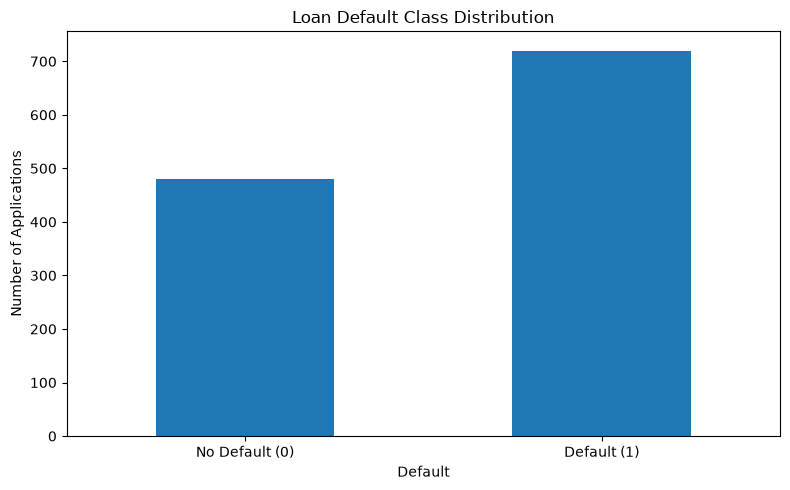

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

target_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Loan Default Class Distribution")
ax.set_xlabel("Default")
ax.set_ylabel("Number of Applications")
ax.set_xticklabels(
    ["No Default (0)", "Default (1)"],
    rotation=0
)

fig.tight_layout()

chart_path = output_dir / "target_distribution.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

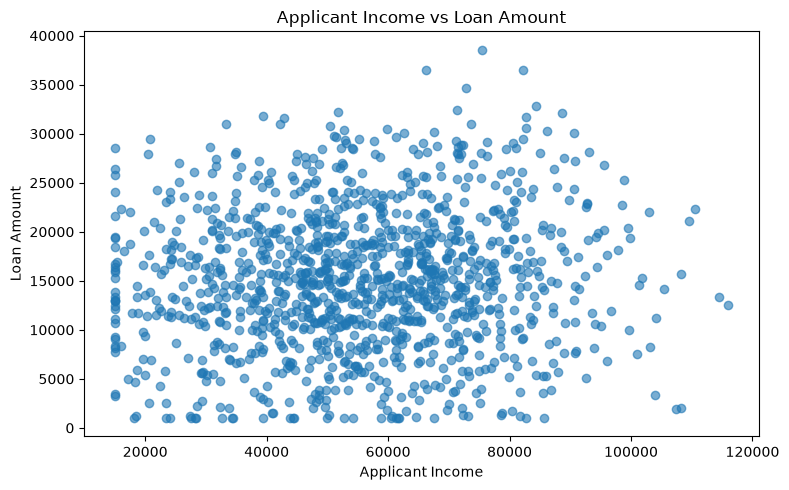

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    loans["applicant_income"],
    loans["loan_amount"],
    alpha=0.6
)

ax.set_title("Applicant Income vs Loan Amount")
ax.set_xlabel("Applicant Income")
ax.set_ylabel("Loan Amount")

fig.tight_layout()

chart_path = output_dir / "income_vs_loan_amount.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
employment_counts = (
    loans["employment_type"]
    .value_counts()
)

display(
    employment_counts.to_frame("Count")
)

,Count
employment_type,
Salaried,584
Self-Employed,355
Contract,261


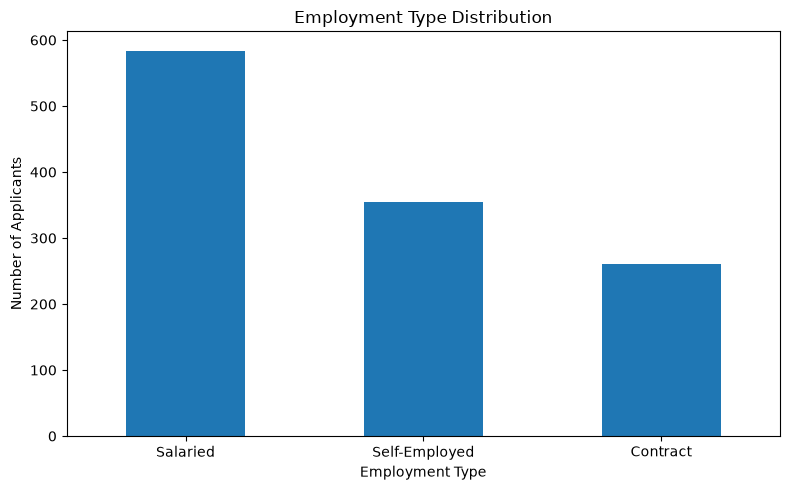

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

employment_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Employment Type Distribution")
ax.set_xlabel("Employment Type")
ax.set_ylabel("Number of Applicants")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

chart_path = output_dir / "employment_type_distribution.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
numerical_columns = loans.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = loans.select_dtypes(
    include=["object", "category"]
).columns.tolist()

display(
    Markdown(
        f"""
### Diagnosis Summary

The dataset contains **{rows} observations** across **{columns} columns**.

There are **{len(numerical_columns)} numerical columns** and
**{len(categorical_columns)} categorical columns**.

The `credit_score` feature contains **{credit_score_missing} missing
values**, while the target variable contains **{default_count} default
cases** and **{non_default_count} non-default cases**.

The missing `credit_score` values require special attention because the
assessment explicitly requires the imputation value to be calculated from
the training set only.
"""
    )
)

C:\Users\M. Subhan\AppData\Local\Temp\ipykernel_23488\371269839.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = loans.select_dtypes(



### Diagnosis Summary

The dataset contains **1200 observations** across **6 columns**.

There are **5 numerical columns** and
**1 categorical columns**.

The `credit_score` feature contains **90 missing
values**, while the target variable contains **720 default
cases** and **480 non-default cases**.

The missing `credit_score` values require special attention because the
assessment explicitly requires the imputation value to be calculated from
the training set only.


## 1.7 Feature Construction

The target variable is `default`, where:

- `0` = applicant did not default
- `1` = applicant defaulted

The model features are `credit_score`, `applicant_income`,
`loan_amount`, and `employment_type`.

The categorical `employment_type` feature is converted into numerical
one-hot encoded columns using `drop_first=True`.

In [18]:
X = loans[
    [
        "credit_score",
        "applicant_income",
        "loan_amount",
        "employment_type"
    ]
].copy()

X = pd.get_dummies(
    X,
    columns=["employment_type"],
    drop_first=True
)

y = loans["default"].copy()

In [19]:
display(X.head())

,credit_score,applicant_income,loan_amount,employment_type_Salaried,employment_type_Self-Employed
0,731.0,78406.0,8301.0,False,False
1,717.0,59130.0,6699.0,False,False
2,713.0,71809.0,4456.0,True,False
3,625.0,41497.0,20290.0,True,False
4,652.0,64193.0,10890.0,True,False


In [20]:
display(
    pd.DataFrame({
        "Feature": X.columns,
        "Data Type": X.dtypes.astype(str).values
    })
)

,Feature,Data Type
0,credit_score,float64
1,applicant_income,float64
2,loan_amount,float64
3,employment_type_Salaried,bool
4,employment_type_Self-Employed,bool


In [21]:
original_feature_count = 4
encoded_feature_count = X.shape[1]
target_name = y.name

display(Markdown(
    f"""
### Feature Construction Finding

The original feature set contained **{original_feature_count} features**.
After one-hot encoding `employment_type`, the model input contains
**{encoded_feature_count} features**.

The prediction target is **`{target_name}`**, where `1` represents
a loan default and `0` represents no default.
"""
))


### Feature Construction Finding

The original feature set contained **4 features**.
After one-hot encoding `employment_type`, the model input contains
**5 features**.

The prediction target is **`default`**, where `1` represents
a loan default and `0` represents no default.


## 2. Train/Test Split

The dataset is split into training and testing subsets using an 80/20
split. Stratification is used to preserve the class distribution of
the target variable in both subsets.

The split is performed before missing-value imputation to prevent
information leakage from the test set into the training process.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (960, 5)
Testing features: (240, 5)
Training target: (960,)
Testing target: (240,)


In [24]:
train_default_rate = y_train.mean()
test_default_rate = y_test.mean()

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [len(y_train), len(y_test)],
    "Default Count": [y_train.sum(), y_test.sum()],
    "Default Rate": [train_default_rate, test_default_rate]
})

display(split_summary)

,Dataset,Samples,Default Count,Default Rate
0,Training,960,576,0.6
1,Testing,240,144,0.6


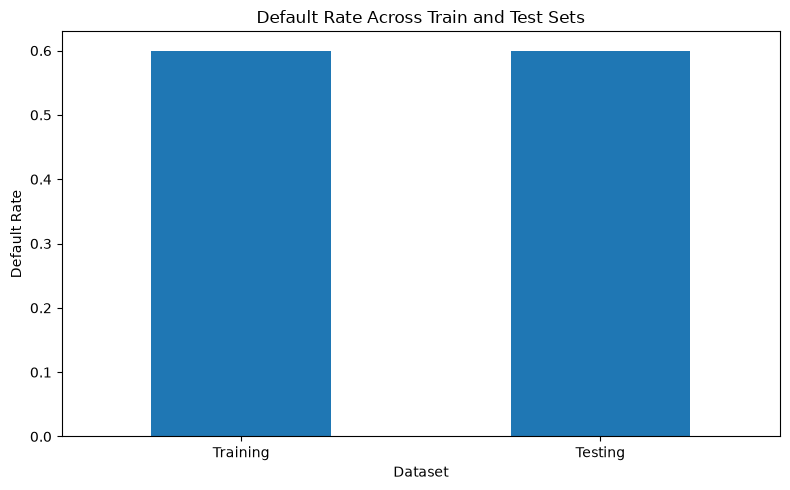

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

split_summary.plot(
    x="Dataset",
    y="Default Rate",
    kind="bar",
    ax=ax,
    legend=False
)

ax.set_title("Default Rate Across Train and Test Sets")
ax.set_xlabel("Dataset")
ax.set_ylabel("Default Rate")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

chart_path = output_dir / "train_test_default_rate.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

In [26]:
display(Markdown(
    f"""
### Split Finding

The training set contains **{len(X_train)} samples**, while the test
set contains **{len(X_test)} samples**.

The default rate is **{train_default_rate:.2%}** in training data and
**{test_default_rate:.2%}** in testing data.

Because stratification was used, the class proportions remain closely
aligned between the two subsets.
"""
))


### Split Finding

The training set contains **960 samples**, while the test
set contains **240 samples**.

The default rate is **60.00%** in training data and
**60.00%** in testing data.

Because stratification was used, the class proportions remain closely
aligned between the two subsets.


## 3. Train-Only Imputation

Missing `credit_score` values are replaced using the median calculated
from the training set only.

The same training-derived median is then applied to both training and
testing data.

The test set is never used to calculate the imputation statistic.

In [27]:
credit_score_imputation_value = X_train["credit_score"].median()

train_missing_before = X_train["credit_score"].isna().sum()
test_missing_before = X_test["credit_score"].isna().sum()

print(
    f"Training-set credit score median: "
    f"{credit_score_imputation_value:.2f}"
)

print(
    f"Missing values in training set before imputation: "
    f"{train_missing_before}"
)

print(
    f"Missing values in test set before imputation: "
    f"{test_missing_before}"
)

Training-set credit score median: 649.00
Missing values in training set before imputation: 71
Missing values in test set before imputation: 19


In [28]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["credit_score"] = X_train["credit_score"].fillna(
    credit_score_imputation_value
)

X_test["credit_score"] = X_test["credit_score"].fillna(
    credit_score_imputation_value
)

In [29]:
train_missing_after = X_train["credit_score"].isna().sum()
test_missing_after = X_test["credit_score"].isna().sum()

print(
    f"Missing values in training set after imputation: "
    f"{train_missing_after}"
)

print(
    f"Missing values in test set after imputation: "
    f"{test_missing_after}"
)

Missing values in training set after imputation: 0
Missing values in test set after imputation: 0


In [30]:
full_dataset_median = loans["credit_score"].median()

display(Markdown(
    f"""
### Imputation Finding

The training-only median used for imputation is **{credit_score_imputation_value:.2f}**.

For comparison, the median calculated from the entire dataset would be
**{full_dataset_median:.2f}**.

The full-dataset value was calculated only for demonstration and was
**not used in the ML pipeline**.

Using the entire dataset before splitting would allow information from
the eventual test set to influence preprocessing, creating a form of
**data leakage**.
"""
))


### Imputation Finding

The training-only median used for imputation is **649.00**.

For comparison, the median calculated from the entire dataset would be
**650.00**.

The full-dataset value was calculated only for demonstration and was
**not used in the ML pipeline**.

Using the entire dataset before splitting would allow information from
the eventual test set to influence preprocessing, creating a form of
**data leakage**.


## 4. Baseline Model

A `DummyClassifier` using the `most_frequent` strategy is trained as
the baseline.

The baseline ignores all feature relationships and always predicts
the majority class from the training data.

All later models will be evaluated against this reference point.

In [31]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.4,0.6]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](5,)","['credit_score','applicant_income','loan_amount', 'employment_type_Salaried','employment_type_Self-Employed']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,5
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [32]:
baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

In [33]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        )
    }

    return metrics, predictions, probabilities

In [34]:
baseline_metrics, baseline_predictions, baseline_probabilities = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

In [35]:
baseline_metrics_df = pd.DataFrame(
    [baseline_metrics],
    index=["Baseline"]
)

display(baseline_metrics_df)

,accuracy,precision,recall,f1,roc_auc
Baseline,0.6,0.6,1.0,0.75,0.5


In [36]:
display(Markdown(
    f"""
### Baseline Finding

The majority-class baseline achieved:

- **Accuracy:** {baseline_metrics["accuracy"]:.3f}
- **Precision:** {baseline_metrics["precision"]:.3f}
- **Recall:** {baseline_metrics["recall"]:.3f}
- **F1:** {baseline_metrics["f1"]:.3f}
- **ROC-AUC:** {baseline_metrics["roc_auc"]:.3f}

This baseline provides the minimum reference point that the trained
machine-learning models should improve upon.
"""
))


### Baseline Finding

The majority-class baseline achieved:

- **Accuracy:** 0.600
- **Precision:** 0.600
- **Recall:** 1.000
- **F1:** 0.750
- **ROC-AUC:** 0.500

This baseline provides the minimum reference point that the trained
machine-learning models should improve upon.


## 5. Logistic Regression

Logistic Regression is trained using the training subset only.

Standardization is applied before training so that numerical features
with different scales are placed on a comparable scale. The scaler is
fitted only on the training data and then applied to the test data,
preventing data leakage.

In [37]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['credit_score','applicant_income','loan_amount', 'employment_type_Salaried','employment_type_Self-Employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [38]:
logistic_metrics, logistic_predictions, logistic_probabilities = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

logistic_metrics_df = pd.DataFrame(
    [logistic_metrics],
    index=["Logistic Regression"]
)

display(logistic_metrics_df)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.745833,0.767742,0.826389,0.795987,0.845414


In [39]:
display(Markdown(
    f"""
### Logistic Regression Finding

Logistic Regression achieved:

- **Accuracy:** {logistic_metrics["accuracy"]:.3f}
- **Precision:** {logistic_metrics["precision"]:.3f}
- **Recall:** {logistic_metrics["recall"]:.3f}
- **F1:** {logistic_metrics["f1"]:.3f}
- **ROC-AUC:** {logistic_metrics["roc_auc"]:.3f}

Compared with the baseline, the model provides a learned prediction
of default risk rather than simply predicting the majority class.
"""
))


### Logistic Regression Finding

Logistic Regression achieved:

- **Accuracy:** 0.746
- **Precision:** 0.768
- **Recall:** 0.826
- **F1:** 0.796
- **ROC-AUC:** 0.845

Compared with the baseline, the model provides a learned prediction
of default risk rather than simply predicting the majority class.


In [40]:
model_results = {
    "baseline": baseline_metrics,
    "logistic_regression": logistic_metrics
}

display(pd.DataFrame(model_results).T)

,accuracy,precision,recall,f1,roc_auc
baseline,0.600000,0.600000,1.000000,0.750000,0.500000
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414


## 5.1 Decision Tree Model

A Decision Tree Classifier is trained on the same training features
and target used by Logistic Regression.

The tree is constrained using `max_depth` and `min_samples_leaf` to
reduce the risk of overfitting.

No test-set information is used during model training.

In [41]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [42]:
decision_tree_metrics, decision_tree_predictions, decision_tree_probabilities = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

In [43]:
decision_tree_metrics_df = pd.DataFrame(
    [decision_tree_metrics],
    index=["Decision Tree"]
)

display(decision_tree_metrics_df)

,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.75,0.808824,0.763889,0.785714,0.840459


In [44]:
display(Markdown(
    f"""
### Decision Tree Finding

The Decision Tree achieved:

- **Accuracy:** {decision_tree_metrics["accuracy"]:.3f}
- **Precision:** {decision_tree_metrics["precision"]:.3f}
- **Recall:** {decision_tree_metrics["recall"]:.3f}
- **F1:** {decision_tree_metrics["f1"]:.3f}
- **ROC-AUC:** {decision_tree_metrics["roc_auc"]:.3f}

The tree can capture nonlinear relationships and feature interactions
that may not be represented as effectively by a linear model.
"""
))


### Decision Tree Finding

The Decision Tree achieved:

- **Accuracy:** 0.750
- **Precision:** 0.809
- **Recall:** 0.764
- **F1:** 0.786
- **ROC-AUC:** 0.840

The tree can capture nonlinear relationships and feature interactions
that may not be represented as effectively by a linear model.


In [45]:
tree_depth = decision_tree_model.get_depth()
tree_leaves = decision_tree_model.get_n_leaves()

display(Markdown(
    f"""
### Tree Complexity

The trained Decision Tree has a maximum depth of **{tree_depth}**
and contains **{tree_leaves} leaf nodes**.

Limiting tree complexity helps reduce the risk of learning noise
specific to the training data.
"""
))


### Tree Complexity

The trained Decision Tree has a maximum depth of **5**
and contains **27 leaf nodes**.

Limiting tree complexity helps reduce the risk of learning noise
specific to the training data.


In [46]:
feature_importance = pd.Series(
    decision_tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(feature_importance.to_frame("Importance"))

,Importance
credit_score,0.734855
applicant_income,0.132956
loan_amount,0.127370
employment_type_Salaried,0.004819
employment_type_Self-Employed,0.000000


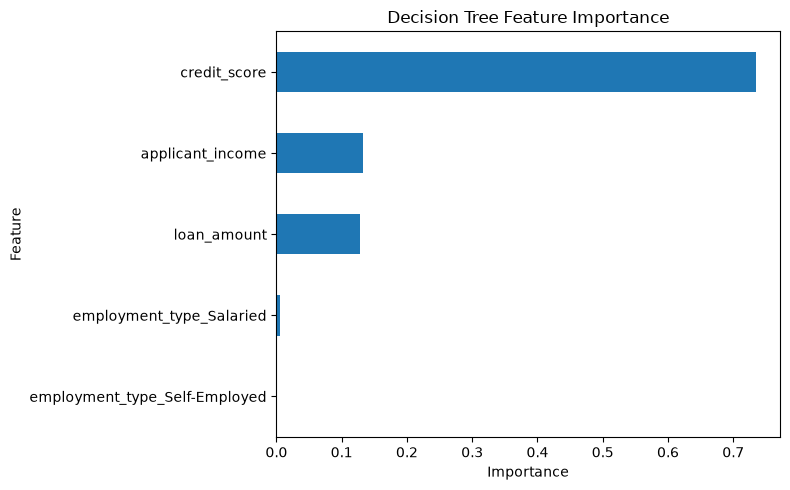

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Decision Tree Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()

chart_path = output_dir / "decision_tree_feature_importance.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

In [48]:
top_tree_feature = feature_importance.index[0]
top_tree_importance = feature_importance.iloc[0]

display(Markdown(
    f"""
### Feature Importance Finding

The feature with the highest Decision Tree importance is
**`{top_tree_feature}`**, with an importance score of
**{top_tree_importance:.3f}**.

Feature importance indicates how useful a feature was for the tree's
splitting decisions. It does **not** by itself prove that the feature
causes loan defaults.
"""
))


### Feature Importance Finding

The feature with the highest Decision Tree importance is
**`credit_score`**, with an importance score of
**0.735**.

Feature importance indicates how useful a feature was for the tree's
splitting decisions. It does **not** by itself prove that the feature
causes loan defaults.


In [49]:
model_results = {
    "baseline": baseline_metrics,
    "logistic_regression": logistic_metrics,
    "decision_tree": decision_tree_metrics
}

comparison_so_far = pd.DataFrame(model_results).T

display(comparison_so_far)

,accuracy,precision,recall,f1,roc_auc
baseline,0.600000,0.600000,1.000000,0.750000,0.500000
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414
decision_tree,0.750000,0.808824,0.763889,0.785714,0.840459


## 5.2 Random Forest Model

A Random Forest Classifier is trained using the same training data and
features as the previous models.

The forest contains multiple decision trees whose predictions are
aggregated to produce the final prediction.

Tree depth and minimum leaf size are constrained to reduce overfitting.

In [50]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [51]:
random_forest_metrics, random_forest_predictions, random_forest_probabilities = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

In [52]:
random_forest_metrics_df = pd.DataFrame(
    [random_forest_metrics],
    index=["Random Forest"]
)

display(random_forest_metrics_df)

,accuracy,precision,recall,f1,roc_auc
Random Forest,0.766667,0.789474,0.833333,0.810811,0.846716


In [53]:
display(Markdown(
    f"""
### Random Forest Finding

The Random Forest achieved:

- **Accuracy:** {random_forest_metrics["accuracy"]:.3f}
- **Precision:** {random_forest_metrics["precision"]:.3f}
- **Recall:** {random_forest_metrics["recall"]:.3f}
- **F1:** {random_forest_metrics["f1"]:.3f}
- **ROC-AUC:** {random_forest_metrics["roc_auc"]:.3f}

The Random Forest combines multiple decision trees, allowing it to
capture nonlinear relationships while generally being more robust
than relying on a single tree.
"""
))


### Random Forest Finding

The Random Forest achieved:

- **Accuracy:** 0.767
- **Precision:** 0.789
- **Recall:** 0.833
- **F1:** 0.811
- **ROC-AUC:** 0.847

The Random Forest combines multiple decision trees, allowing it to
capture nonlinear relationships while generally being more robust
than relying on a single tree.


In [54]:
model_results = {
    "baseline": baseline_metrics,
    "logistic_regression": logistic_metrics,
    "decision_tree": decision_tree_metrics,
    "random_forest": random_forest_metrics
}

model_comparison = pd.DataFrame(model_results).T

display(model_comparison)

,accuracy,precision,recall,f1,roc_auc
baseline,0.600000,0.600000,1.000000,0.750000,0.500000
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414
decision_tree,0.750000,0.808824,0.763889,0.785714,0.840459
random_forest,0.766667,0.789474,0.833333,0.810811,0.846716


In [55]:
best_by_metric = model_comparison.idxmax()

display(best_by_metric.to_frame("Best Model"))

,Best Model
accuracy,random_forest
precision,decision_tree
recall,baseline
f1,random_forest
roc_auc,random_forest


In [56]:
best_accuracy_model = model_comparison["accuracy"].idxmax()
best_recall_model = model_comparison["recall"].idxmax()
best_f1_model = model_comparison["f1"].idxmax()
best_auc_model = model_comparison["roc_auc"].idxmax()

display(Markdown(
    f"""
### Model Comparison Finding

Based on the held-out test set:

- The highest **accuracy** was achieved by **{best_accuracy_model}**
  with **{model_comparison.loc[best_accuracy_model, "accuracy"]:.3f}**.
- The highest **recall** was achieved by **{best_recall_model}**
  with **{model_comparison.loc[best_recall_model, "recall"]:.3f}**.
- The highest **F1 score** was achieved by **{best_f1_model}**
  with **{model_comparison.loc[best_f1_model, "f1"]:.3f}**.
- The highest **ROC-AUC** was achieved by **{best_auc_model}**
  with **{model_comparison.loc[best_auc_model, "roc_auc"]:.3f}**.

The final model should therefore be selected based on the assessment's
risk context rather than automatically choosing the model with the
highest accuracy.
"""
))


### Model Comparison Finding

Based on the held-out test set:

- The highest **accuracy** was achieved by **random_forest**
  with **0.767**.
- The highest **recall** was achieved by **baseline**
  with **1.000**.
- The highest **F1 score** was achieved by **random_forest**
  with **0.811**.
- The highest **ROC-AUC** was achieved by **random_forest**
  with **0.847**.

The final model should therefore be selected based on the assessment's
risk context rather than automatically choosing the model with the
highest accuracy.


In [57]:
rf_feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(
    rf_feature_importance.to_frame("Importance")
)

,Importance
credit_score,0.615526
applicant_income,0.183854
loan_amount,0.167492
employment_type_Salaried,0.019905
employment_type_Self-Employed,0.013224


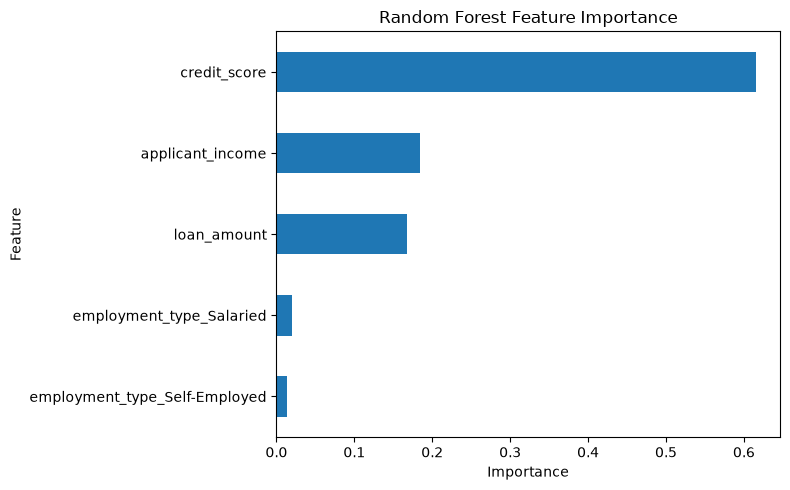

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))

rf_feature_importance.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()

chart_path = output_dir / "random_forest_feature_importance.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

In [59]:
top_rf_feature = rf_feature_importance.index[0]
top_rf_importance = rf_feature_importance.iloc[0]

display(Markdown(
    f"""
### Random Forest Feature Importance Finding

The feature with the highest Random Forest importance is
**`{top_rf_feature}`**, with an importance score of
**{top_rf_importance:.3f}**.

This indicates that the feature contributed strongly to the forest's
prediction process. Feature importance should not be interpreted as
proof of causation.
"""
))


### Random Forest Feature Importance Finding

The feature with the highest Random Forest importance is
**`credit_score`**, with an importance score of
**0.616**.

This indicates that the feature contributed strongly to the forest's
prediction process. Feature importance should not be interpreted as
proof of causation.


# 5.3 Hyperparameter Tuning

The initial versions of Logistic Regression, Decision Tree, and Random
Forest have been trained in the previous sections. However, the
assessment requires the model hyperparameters to be tuned.

Hyperparameter tuning is performed using 5-fold cross-validation on the
training data only. The test set remains completely untouched during
this process.

The purpose of tuning is to identify model configurations that provide
a good balance between precision and recall before performing the final
evaluation on the held-out test set.

Because the positive class represents loan default (`default = 1`),
F1-score is used as the tuning objective. F1-score balances precision
and recall and is therefore more appropriate than relying on accuracy
alone for this risk-oriented classification task.

## Training-Only Cross-Validation

The test set represents unseen applicants and must remain independent
from all model-development decisions.

Therefore, hyperparameter tuning is performed only using `X_train` and
`y_train`.

Five-fold cross-validation divides the training data into five folds.
For each hyperparameter configuration, four folds are used for training
and one fold is used for validation. This process is repeated so that
each fold serves as validation data once.

The configuration with the strongest average validation F1-score is
selected.

After tuning is complete, the selected model is evaluated exactly once
on `X_test` and `y_test` for the final performance estimates.

## Logistic Regression Hyperparameter Tuning

For Logistic Regression, the main hyperparameter being tuned is `C`.

The parameter `C` controls the strength of regularization:

- Smaller values apply stronger regularization.
- Larger values apply weaker regularization.

Several values are evaluated using 5-fold cross-validation.

Standardization is included inside the pipeline so that the scaler is
fitted independently within each training fold. This prevents
information from validation folds from influencing the preprocessing
during cross-validation.

In [60]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

logistic_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, w

In [61]:
logistic_best_params = logistic_grid.best_params_
logistic_best_cv_f1 = logistic_grid.best_score_

display(Markdown(
    f"""
### Logistic Regression Tuning Result

The best Logistic Regression configuration selected through 5-fold
cross-validation was:

**{logistic_best_params}**

The corresponding mean cross-validation F1-score was
**{logistic_best_cv_f1:.3f}**.

The test set was not used during this selection process.
"""
))


### Logistic Regression Tuning Result

The best Logistic Regression configuration selected through 5-fold
cross-validation was:

**{'classifier__C': 1}**

The corresponding mean cross-validation F1-score was
**0.821**.

The test set was not used during this selection process.


In [62]:
logistic_model = logistic_grid.best_estimator_

## Decision Tree Hyperparameter Tuning

A Decision Tree can easily become too complex and overfit the training
data.

Two important complexity-related hyperparameters are therefore tuned:

- `max_depth`: limits the maximum depth of the tree.
- `min_samples_leaf`: controls the minimum number of observations
  allowed in a leaf.

Different combinations are evaluated using 5-fold cross-validation on
the training data.

In [63]:
decision_tree_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [2, 5, 10, 20]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

decision_tree_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [64]:
decision_tree_best_params = decision_tree_grid.best_params_
decision_tree_best_cv_f1 = decision_tree_grid.best_score_

display(Markdown(
    f"""
### Decision Tree Tuning Result

The best Decision Tree configuration selected through 5-fold
cross-validation was:

**{decision_tree_best_params}**

The corresponding mean cross-validation F1-score was
**{decision_tree_best_cv_f1:.3f}**.

Restricting tree complexity helps reduce the possibility of
overfitting the training observations.
"""
))


### Decision Tree Tuning Result

The best Decision Tree configuration selected through 5-fold
cross-validation was:

**{'max_depth': 7, 'min_samples_leaf': 20}**

The corresponding mean cross-validation F1-score was
**0.783**.

Restricting tree complexity helps reduce the possibility of
overfitting the training observations.


In [65]:
decision_tree_model = decision_tree_grid.best_estimator_

## Random Forest Hyperparameter Tuning

Random Forest combines multiple Decision Trees. Its performance and
complexity are influenced by several hyperparameters.

The following parameters are tuned:

- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum depth of each tree.
- `min_samples_leaf`: minimum number of samples allowed in a leaf.

The combinations are evaluated using 5-fold cross-validation on the
training data only.

In [66]:
random_forest_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 12, None],
    "min_samples_leaf": [2, 5, 10]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=random_forest_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

random_forest_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [67]:
number_of_configurations = (
    len(random_forest_param_grid["n_estimators"])
    * len(random_forest_param_grid["max_depth"])
    * len(random_forest_param_grid["min_samples_leaf"])
)

display(Markdown(
    f"""
The Random Forest search evaluates **{number_of_configurations}**
different hyperparameter combinations using 5-fold cross-validation.
"""
))


The Random Forest search evaluates **36**
different hyperparameter combinations using 5-fold cross-validation.


In [68]:
random_forest_best_params = random_forest_grid.best_params_
random_forest_best_cv_f1 = random_forest_grid.best_score_

display(Markdown(
    f"""
### Random Forest Tuning Result

The best Random Forest configuration selected through 5-fold
cross-validation was:

**{random_forest_best_params}**

The corresponding mean cross-validation F1-score was
**{random_forest_best_cv_f1:.3f}**.

The test set remained untouched during this tuning process.
"""
))


### Random Forest Tuning Result

The best Random Forest configuration selected through 5-fold
cross-validation was:

**{'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}**

The corresponding mean cross-validation F1-score was
**0.816**.

The test set remained untouched during this tuning process.


In [69]:
random_forest_model = random_forest_grid.best_estimator_

In [70]:
tuning_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Best Parameters": [
        str(logistic_grid.best_params_),
        str(decision_tree_grid.best_params_),
        str(random_forest_grid.best_params_)
    ],
    "Best CV F1": [
        logistic_grid.best_score_,
        decision_tree_grid.best_score_,
        random_forest_grid.best_score_
    ]
})

display(tuning_summary)

,Model,Best Parameters,Best CV F1
0,Logistic Regression,{'classifier__C': 1},0.821164
1,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 20}",0.783016
2,Random Forest,"{'max_depth': 5, 'min_samples_leaf': 2, 'n_est...",0.815604


In [71]:
display(Markdown(
    f"""
### Hyperparameter Tuning Summary

All three machine-learning models were tuned using **5-fold
cross-validation on the training set only**.

- **Logistic Regression:** best CV F1 = **{logistic_grid.best_score_:.3f}**
- **Decision Tree:** best CV F1 = **{decision_tree_grid.best_score_:.3f}**
- **Random Forest:** best CV F1 = **{random_forest_grid.best_score_:.3f}**

The selected configurations were determined without using the
held-out test set.

The tuned estimators will now be evaluated on `X_test` and `y_test`
using accuracy, precision, recall, F1-score, and ROC-AUC.
"""
))


### Hyperparameter Tuning Summary

All three machine-learning models were tuned using **5-fold
cross-validation on the training set only**.

- **Logistic Regression:** best CV F1 = **0.821**
- **Decision Tree:** best CV F1 = **0.783**
- **Random Forest:** best CV F1 = **0.816**

The selected configurations were determined without using the
held-out test set.

The tuned estimators will now be evaluated on `X_test` and `y_test`
using accuracy, precision, recall, F1-score, and ROC-AUC.


## 6. Model Evaluation

To compare the performance of all trained models fairly, including the baseline, we compute five classification metrics on the same held-out test set:

- **Accuracy** — overall proportion of correct predictions.
- **Precision** — proportion of predicted defaults that were actually defaults.
- **Recall** — proportion of actual defaults correctly identified by the model.
- **F1 Score** — harmonic mean of precision and recall, providing a balance between the two.
- **ROC-AUC** — measures how well the model distinguishes between default and non-default applicants across different classification thresholds.

All metrics are calculated using only the **untouched test set** so that model performance reflects generalization to unseen data.

In [72]:
logistic_metrics, logistic_predictions, logistic_probabilities = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

decision_tree_metrics, decision_tree_predictions, decision_tree_probabilities = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

random_forest_metrics, random_forest_predictions, random_forest_probabilities = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

## 6.1 Final Test-Set Evaluation

After hyperparameter tuning was completed using the training data,
the selected models were evaluated on the held-out test set.

The following five metrics are reported for every model:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The baseline is included as a reference point.

In [73]:
model_results = {
    "baseline": baseline_metrics,
    "logistic_regression": logistic_metrics,
    "decision_tree": decision_tree_metrics,
    "random_forest": random_forest_metrics
}

model_comparison = pd.DataFrame(model_results).T

display(model_comparison)

,accuracy,precision,recall,f1,roc_auc
baseline,0.600000,0.600000,1.000000,0.750000,0.500000
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414
decision_tree,0.729167,0.765101,0.791667,0.778157,0.825774
random_forest,0.770833,0.783439,0.854167,0.817276,0.854094


In [74]:
best_accuracy_model = model_comparison["accuracy"].idxmax()
best_precision_model = model_comparison["precision"].idxmax()
best_recall_model = model_comparison["recall"].idxmax()
best_f1_model = model_comparison["f1"].idxmax()
best_auc_model = model_comparison["roc_auc"].idxmax()

display(Markdown(
    f"""
### Final Test-Set Evaluation Finding

On the held-out test set:

- The highest **accuracy** was achieved by
  **{best_accuracy_model}** with a score of
  **{model_comparison.loc[best_accuracy_model, "accuracy"]:.3f}**.
- The highest **precision** was achieved by
  **{best_precision_model}** with a score of
  **{model_comparison.loc[best_precision_model, "precision"]:.3f}**.
- The highest **recall** was achieved by
  **{best_recall_model}** with a score of
  **{model_comparison.loc[best_recall_model, "recall"]:.3f}**.
- The highest **F1-score** was achieved by
  **{best_f1_model}** with a score of
  **{model_comparison.loc[best_f1_model, "f1"]:.3f}**.
- The highest **ROC-AUC** was achieved by
  **{best_auc_model}** with a score of
  **{model_comparison.loc[best_auc_model, "roc_auc"]:.3f}**.

These results will be used in the next section to select and justify
the final model.
"""
))


### Final Test-Set Evaluation Finding

On the held-out test set:

- The highest **accuracy** was achieved by
  **random_forest** with a score of
  **0.771**.
- The highest **precision** was achieved by
  **random_forest** with a score of
  **0.783**.
- The highest **recall** was achieved by
  **baseline** with a score of
  **1.000**.
- The highest **F1-score** was achieved by
  **random_forest** with a score of
  **0.817**.
- The highest **ROC-AUC** was achieved by
  **random_forest** with a score of
  **0.854**.

These results will be used in the next section to select and justify
the final model.


## Conclusion

Hyperparameter tuning has been completed for Logistic Regression,
Decision Tree, and Random Forest using 5-fold cross-validation.

The tuning process was restricted to the training data, ensuring that
the held-out test set remained independent of hyperparameter selection.

The tuned models have now been evaluated on the same test set using
accuracy, precision, recall, F1-score, and ROC-AUC.

The next stage is to compare these results in the context of loan
default prediction and select the final model for error analysis and
calibration.

## 6.2 Test-Set Performance Comparison

The tuned models are compared using five evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

All metrics are calculated on the same held-out test set containing
20% of the original dataset.

Because the prediction target is loan default, recall is particularly
important because a false negative represents an applicant who actually
defaults but was predicted as a non-defaulter.

However, recall should not be considered in isolation. A model that
identifies almost every default by labeling most applicants as
defaulters could have poor precision.

Therefore, F1-score and ROC-AUC are also considered when selecting the
final model.

In [75]:
display(model_comparison)

,accuracy,precision,recall,f1,roc_auc
baseline,0.600000,0.600000,1.000000,0.750000,0.500000
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414
decision_tree,0.729167,0.765101,0.791667,0.778157,0.825774
random_forest,0.770833,0.783439,0.854167,0.817276,0.854094


In [76]:
baseline_recall = model_comparison.loc["baseline", "recall"]
baseline_accuracy = model_comparison.loc["baseline", "accuracy"]
baseline_auc = model_comparison.loc["baseline", "roc_auc"]

display(Markdown(
    f"""
### Baseline Finding

The baseline achieved a recall of **{baseline_recall:.3f}**, which is
the highest recall among the evaluated models.

However, its accuracy was only **{baseline_accuracy:.3f}** and its
ROC-AUC was **{baseline_auc:.3f}**.

This happens because the baseline predicts the majority class for
every applicant. Therefore, its perfect recall does not indicate useful
risk discrimination.

This demonstrates why model evaluation should consider multiple
metrics rather than recall or accuracy alone.
"""
))


### Baseline Finding

The baseline achieved a recall of **1.000**, which is
the highest recall among the evaluated models.

However, its accuracy was only **0.600** and its
ROC-AUC was **0.500**.

This happens because the baseline predicts the majority class for
every applicant. Therefore, its perfect recall does not indicate useful
risk discrimination.

This demonstrates why model evaluation should consider multiple
metrics rather than recall or accuracy alone.


In [77]:
lr_rf_comparison = model_comparison.loc[
    ["logistic_regression", "random_forest"]
]

display(lr_rf_comparison)

,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.745833,0.767742,0.826389,0.795987,0.845414
random_forest,0.770833,0.783439,0.854167,0.817276,0.854094


In [78]:
rf_lr_improvement = (
    model_comparison.loc["random_forest"]
    - model_comparison.loc["logistic_regression"]
)

display(
    rf_lr_improvement.to_frame(
        "Random Forest - Logistic Regression"
    )
)

,Random Forest - Logistic Regression
accuracy,0.025000
precision,0.015698
recall,0.027778
f1,0.021289
roc_auc,0.008681


In [79]:
display(Markdown(
    f"""
### Random Forest vs Logistic Regression

Compared with Logistic Regression, Random Forest improved:

- **Accuracy:** {rf_lr_improvement["accuracy"]:+.3f}
- **Precision:** {rf_lr_improvement["precision"]:+.3f}
- **Recall:** {rf_lr_improvement["recall"]:+.3f}
- **F1-score:** {rf_lr_improvement["f1"]:+.3f}
- **ROC-AUC:** {rf_lr_improvement["roc_auc"]:+.3f}

Therefore, Random Forest provides the strongest overall test-set
performance among the evaluated machine-learning models.
"""
))


### Random Forest vs Logistic Regression

Compared with Logistic Regression, Random Forest improved:

- **Accuracy:** +0.025
- **Precision:** +0.016
- **Recall:** +0.028
- **F1-score:** +0.021
- **ROC-AUC:** +0.009

Therefore, Random Forest provides the strongest overall test-set
performance among the evaluated machine-learning models.


### 6.3 Model Comparison Visualization

The model comparison chart focuses on precision, recall, F1-score, and
ROC-AUC.

These metrics are emphasized because the task involves identifying
loan defaults, where both missed defaults and incorrect default
predictions have practical consequences.

Accuracy remains included in the numerical comparison table but is not
used as the sole basis for selecting the final model.

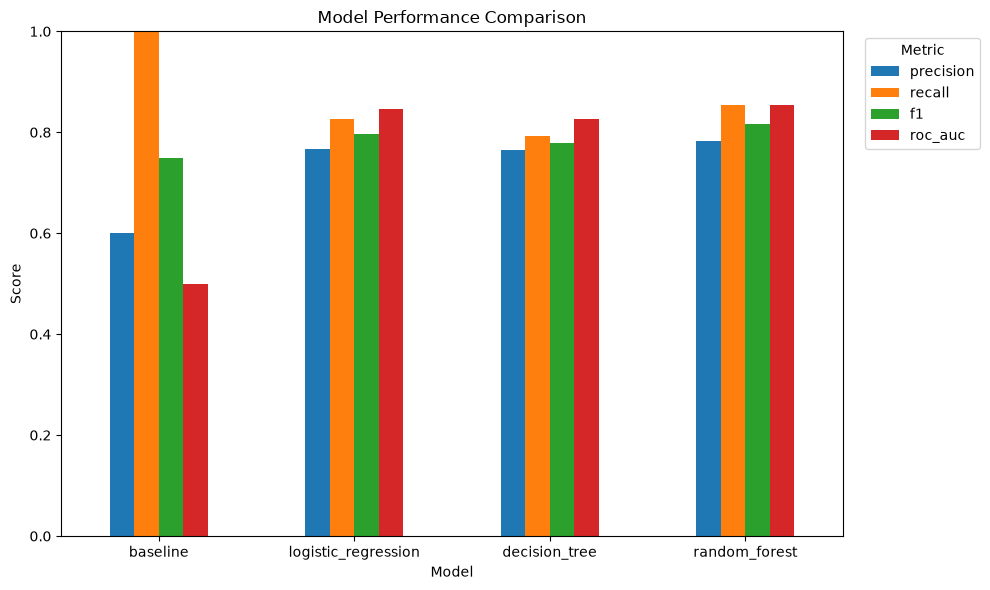

In [80]:
comparison_metrics = [
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

fig, ax = plt.subplots(figsize=(10, 6))

model_comparison[comparison_metrics].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

chart_path = Path("chart_model_comparison.png")
fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
final_model_name = "random_forest"
final_model = random_forest_model

final_predictions = random_forest_predictions
final_probabilities = random_forest_probabilities

In [82]:
final_accuracy = model_comparison.loc[
    final_model_name, "accuracy"
]

final_precision = model_comparison.loc[
    final_model_name, "precision"
]

final_recall = model_comparison.loc[
    final_model_name, "recall"
]

final_f1 = model_comparison.loc[
    final_model_name, "f1"
]

final_auc = model_comparison.loc[
    final_model_name, "roc_auc"
]

display(Markdown(
    f"""
## 6.4 Final Model Selection

The selected final model is **Random Forest**.

It achieved an accuracy of **{final_accuracy:.3f}**, precision of
**{final_precision:.3f}**, recall of **{final_recall:.3f}**, F1-score of
**{final_f1:.3f}**, and ROC-AUC of **{final_auc:.3f}** on the held-out
test set.

Random Forest was selected because it achieved the strongest overall
performance among the trained machine-learning models. In particular,
it achieved the highest F1-score and ROC-AUC while also achieving the
highest accuracy and precision.

Although the baseline achieved a recall of **{baseline_recall:.3f}**,
this was caused by predicting the majority class for every applicant.
Its ROC-AUC of **{baseline_auc:.3f}** demonstrates that it provides no
meaningful ranking or discrimination ability.

Therefore, Random Forest provides a substantially more useful balance
between identifying defaults and avoiding unnecessary default
predictions.
"""
))


## 6.4 Final Model Selection

The selected final model is **Random Forest**.

It achieved an accuracy of **0.771**, precision of
**0.783**, recall of **0.854**, F1-score of
**0.817**, and ROC-AUC of **0.854** on the held-out
test set.

Random Forest was selected because it achieved the strongest overall
performance among the trained machine-learning models. In particular,
it achieved the highest F1-score and ROC-AUC while also achieving the
highest accuracy and precision.

Although the baseline achieved a recall of **1.000**,
this was caused by predicting the majority class for every applicant.
Its ROC-AUC of **0.500** demonstrates that it provides no
meaningful ranking or discrimination ability.

Therefore, Random Forest provides a substantially more useful balance
between identifying defaults and avoiding unnecessary default
predictions.


In [83]:
final_model_snapshot = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Random Forest": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

display(final_model_snapshot)

,Metric,Random Forest
0,Accuracy,0.770833
1,Precision,0.783439
2,Recall,0.854167
3,F1,0.817276
4,ROC-AUC,0.854094


## 6.5 Conclusion

Four models were evaluated on the same held-out test set: a majority-class
baseline, Logistic Regression, Decision Tree, and Random Forest.

The baseline achieved perfect recall because it predicted the majority
class for every applicant, but its ROC-AUC of 0.500 showed that it had no
discriminative ability.

Among the actual machine-learning models, Random Forest achieved the
strongest overall test-set performance, including the highest precision,
F1-score, and ROC-AUC.

Random Forest is therefore selected as the final model for the remaining
error-analysis and calibration stages.

## 7. Test-Set Error Analysis

The final Random Forest model is used to inspect predictions on the
held-out test set.

Each test-set observation is labeled according to whether its
prediction was correct, a false positive, or a false negative.

The analysis focuses only on the held-out test observations so that
the error analysis reflects the model's final generalization
performance.

In [84]:
error_analysis = loans.loc[
    X_test.index,
    [
        "applicant_id",
        "employment_type",
        "credit_score",
        "applicant_income",
        "loan_amount",
        "default"
    ]
].copy()

error_analysis["predicted_default"] = final_predictions
error_analysis["predicted_probability"] = final_probabilities

In [85]:
error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["default"] == 0) &
    (error_analysis["predicted_default"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["default"] == 1) &
    (error_analysis["predicted_default"] == 0),
    "error_type"
] = "False Negative"

In [86]:
display(
    error_analysis["error_type"]
    .value_counts()
    .to_frame("Count")
)

,Count
error_type,
Correct,185
False Positive,34
False Negative,21


In [87]:
false_positives = error_analysis[
    error_analysis["error_type"] == "False Positive"
]

false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
]

correct_predictions = error_analysis[
    error_analysis["error_type"] == "Correct"
]

total_test_samples = len(error_analysis)

fp_count = len(false_positives)
fn_count = len(false_negatives)
correct_count = len(correct_predictions)
total_errors = fp_count + fn_count

In [88]:
display(Markdown(
    f"""
### Error Summary

The final Random Forest was evaluated on **{total_test_samples}**
test-set applicants.

- **Correct predictions:** {correct_count}
- **False positives:** {fp_count}
- **False negatives:** {fn_count}
- **Total errors:** {total_errors}

The model therefore misclassified **{total_errors / total_test_samples:.2%}**
of the held-out test observations.
"""
))


### Error Summary

The final Random Forest was evaluated on **240**
test-set applicants.

- **Correct predictions:** 185
- **False positives:** 34
- **False negatives:** 21
- **Total errors:** 55

The model therefore misclassified **22.92%**
of the held-out test observations.


In [89]:
misclassified_rows = error_analysis[
    error_analysis["error_type"] != "Correct"
].copy()

display(misclassified_rows)

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default,predicted_default,predicted_probability,error_type
88,89,Contract,650.0,48511.0,18965.0,0,1,0.704338,False Positive
663,664,Contract,629.0,55250.0,11096.0,0,1,0.745944,False Positive
124,125,Salaried,647.0,48595.0,23336.0,0,1,0.757330,False Positive
1018,1019,Contract,710.0,70560.0,16091.0,1,0,0.246121,False Negative
844,845,Salaried,660.0,95036.0,10441.0,1,0,0.307205,False Negative
737,738,Self-Employed,NaN,20544.0,17601.0,0,1,0.762940,False Positive
425,426,Salaried,707.0,48108.0,20962.0,1,0,0.290925,False Negative
218,219,Contract,658.0,83527.0,23569.0,0,1,0.599190,False Positive
924,925,Salaried,674.0,44522.0,25251.0,0,1,0.545322,False Positive
128,129,Salaried,NaN,74245.0,13162.0,0,1,0.516716,False Positive


In [90]:
display(
    false_positives[
        [
            "applicant_id",
            "employment_type",
            "credit_score",
            "applicant_income",
            "loan_amount",
            "default",
            "predicted_default",
            "predicted_probability"
        ]
    ]
)

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default,predicted_default,predicted_probability
88,89,Contract,650.0,48511.0,18965.0,0,1,0.704338
663,664,Contract,629.0,55250.0,11096.0,0,1,0.745944
124,125,Salaried,647.0,48595.0,23336.0,0,1,0.757330
737,738,Self-Employed,NaN,20544.0,17601.0,0,1,0.762940
218,219,Contract,658.0,83527.0,23569.0,0,1,0.599190
924,925,Salaried,674.0,44522.0,25251.0,0,1,0.545322
128,129,Salaried,NaN,74245.0,13162.0,0,1,0.516716
1186,1187,Salaried,NaN,25705.0,21346.0,0,1,0.821412
1148,1149,Self-Employed,661.0,39906.0,19176.0,0,1,0.564377
773,774,Salaried,690.0,35742.0,26593.0,0,1,0.584154


In [91]:
display(
    false_negatives[
        [
            "applicant_id",
            "employment_type",
            "credit_score",
            "applicant_income",
            "loan_amount",
            "default",
            "predicted_default",
            "predicted_probability"
        ]
    ]
)

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default,predicted_default,predicted_probability
1018,1019,Contract,710.0,70560.0,16091.0,1,0,0.246121
844,845,Salaried,660.0,95036.0,10441.0,1,0,0.307205
425,426,Salaried,707.0,48108.0,20962.0,1,0,0.290925
717,718,Contract,657.0,88472.0,18404.0,1,0,0.439403
418,419,Self-Employed,663.0,64714.0,11447.0,1,0,0.420864
189,190,Self-Employed,662.0,92981.0,19165.0,1,0,0.472790
313,314,Contract,705.0,33273.0,18343.0,1,0,0.497511
807,808,Salaried,680.0,63464.0,10897.0,1,0,0.332858
119,120,Salaried,674.0,60894.0,7213.0,1,0,0.367350
732,733,Self-Employed,684.0,58153.0,12321.0,1,0,0.374107


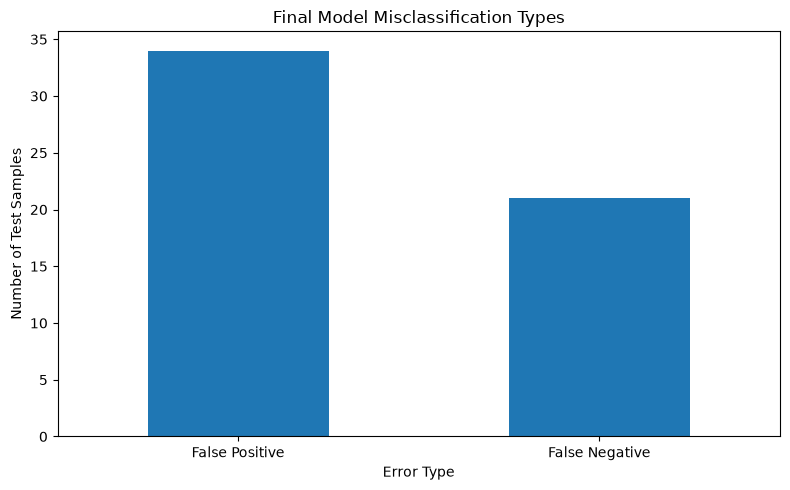

In [92]:
error_counts = pd.Series({
    "False Positive": fp_count,
    "False Negative": fn_count
})

fig, ax = plt.subplots(figsize=(8, 5))

error_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Final Model Misclassification Types")
ax.set_xlabel("Error Type")
ax.set_ylabel("Number of Test Samples")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

chart_path = output_dir / "error_type_counts.png"
fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
error_feature_summary = (
    error_analysis
    .groupby("error_type")[
        [
            "credit_score",
            "applicant_income",
            "loan_amount",
            "predicted_probability"
        ]
    ]
    .mean()
)

display(error_feature_summary)

,credit_score,applicant_income,loan_amount,predicted_probability
error_type,,,,
Correct,644.442529,56364.021622,15710.043243,0.614140
False Negative,687.095238,57975.095238,13931.619048,0.366301
False Positive,645.807692,52066.117647,16813.147059,0.658879


In [94]:
fp_credit = false_positives["credit_score"].mean()
fn_credit = false_negatives["credit_score"].mean()

fp_income = false_positives["applicant_income"].mean()
fn_income = false_negatives["applicant_income"].mean()

fp_loan = false_positives["loan_amount"].mean()
fn_loan = false_negatives["loan_amount"].mean()

fp_probability = false_positives["predicted_probability"].mean()
fn_probability = false_negatives["predicted_probability"].mean()

In [95]:
display(Markdown(
    f"""
### 7.1 Error Pattern Analysis

Among the false positives, the average credit score was
**{fp_credit:.2f}**, average applicant income was
**{fp_income:.2f}**, and average loan amount was
**{fp_loan:.2f}**.

Among the false negatives, the average credit score was
**{fn_credit:.2f}**, average applicant income was
**{fn_income:.2f}**, and average loan amount was
**{fn_loan:.2f}**.

The average predicted default probability was **{fp_probability:.3f}**
for false positives and **{fn_probability:.3f}** for false negatives.

These comparisons help identify whether the model's mistakes tend to
occur among applicants whose feature values produce ambiguous risk
signals.
"""
))


### 7.1 Error Pattern Analysis

Among the false positives, the average credit score was
**645.81**, average applicant income was
**52066.12**, and average loan amount was
**16813.15**.

Among the false negatives, the average credit score was
**687.10**, average applicant income was
**57975.10**, and average loan amount was
**13931.62**.

The average predicted default probability was **0.659**
for false positives and **0.366** for false negatives.

These comparisons help identify whether the model's mistakes tend to
occur among applicants whose feature values produce ambiguous risk
signals.


In [96]:
employment_error_summary = pd.crosstab(
    error_analysis["employment_type"],
    error_analysis["error_type"]
)

display(employment_error_summary)

error_type,Correct,False Negative,False Positive
employment_type,,,
Contract,42,6,4
Salaried,93,10,17
Self-Employed,50,5,13


In [97]:
employment_error_rate = (
    error_analysis.assign(
        is_error=error_analysis["error_type"] != "Correct"
    )
    .groupby("employment_type")["is_error"]
    .mean()
    .sort_values(ascending=False)
)

display(
    employment_error_rate.to_frame("Error Rate")
)

,Error Rate
employment_type,
Self-Employed,0.264706
Salaried,0.225000
Contract,0.192308


In [98]:
highest_error_employment = employment_error_rate.index[0]
highest_error_rate = employment_error_rate.iloc[0]

display(Markdown(
    f"""
### 7.2 Employment-Type Error Finding

The employment category with the highest overall test-set error rate
was **{highest_error_employment}**, with an error rate of
**{highest_error_rate:.2%}**.

This observation describes the model's behavior on this particular
test sample and should not be interpreted as evidence that employment
type itself causes default.
"""
))


### 7.2 Employment-Type Error Finding

The employment category with the highest overall test-set error rate
was **Self-Employed**, with an error rate of
**26.47%**.

This observation describes the model's behavior on this particular
test sample and should not be interpreted as evidence that employment
type itself causes default.


In [99]:
misclassified_rows["distance_from_threshold"] = (
    misclassified_rows["predicted_probability"] - 0.5
).abs()

most_uncertain_errors = (
    misclassified_rows
    .sort_values("distance_from_threshold")
    .head(10)
)

display(most_uncertain_errors)

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default,predicted_default,predicted_probability,error_type,distance_from_threshold
313,314,Contract,705.0,33273.0,18343.0,1,0,0.497511,False Negative,0.002489
128,129,Salaried,NaN,74245.0,13162.0,0,1,0.516716,False Positive,0.016716
169,170,Salaried,656.0,58959.0,14146.0,1,0,0.480014,False Negative,0.019986
532,533,Salaried,660.0,33317.0,11838.0,0,1,0.520848,False Positive,0.020848
189,190,Self-Employed,662.0,92981.0,19165.0,1,0,0.472790,False Negative,0.027210
924,925,Salaried,674.0,44522.0,25251.0,0,1,0.545322,False Positive,0.045322
57,58,Self-Employed,624.0,63881.0,3582.0,0,1,0.550793,False Positive,0.050793
377,378,Salaried,677.0,27707.0,15218.0,0,1,0.558775,False Positive,0.058775
1095,1096,Salaried,652.0,73980.0,26873.0,0,1,0.559122,False Positive,0.059122
717,718,Contract,657.0,88472.0,18404.0,1,0,0.439403,False Negative,0.060597


In [100]:
display(Markdown(
    f"""
## 7.3 Error Analysis Conclusion

The final Random Forest produced **{fp_count} false positives** and
**{fn_count} false negatives** on the held-out test set, for a total of
**{total_errors} misclassified applicants**.

The false-positive group had an average predicted default probability
of **{fp_probability:.3f}**, while the false-negative group had an
average predicted default probability of **{fn_probability:.3f}**.

The feature-level comparisons and employment-type analysis provide
evidence about where the model struggles. In particular, applicants
whose observed characteristics produce less clearly separated risk
signals can be difficult for the model to classify correctly.

The false-negative cases deserve particular attention because they
represent actual defaulters that the model failed to identify.
"""
))


## 7.3 Error Analysis Conclusion

The final Random Forest produced **34 false positives** and
**21 false negatives** on the held-out test set, for a total of
**55 misclassified applicants**.

The false-positive group had an average predicted default probability
of **0.659**, while the false-negative group had an
average predicted default probability of **0.366**.

The feature-level comparisons and employment-type analysis provide
evidence about where the model struggles. In particular, applicants
whose observed characteristics produce less clearly separated risk
signals can be difficult for the model to classify correctly.

The false-negative cases deserve particular attention because they
represent actual defaulters that the model failed to identify.


## 8. Calibration Curve

The calibration curve compares the mean predicted probability of
default with the observed fraction of defaults within probability
bins.

A perfectly calibrated classifier would produce points close to the
diagonal line, meaning that predicted probabilities correspond closely
to observed default frequencies.

In [101]:

prob_true, prob_pred = calibration_curve(
    y_test,
    final_probabilities,
    n_bins=10,
    strategy="uniform"
)

In [102]:
calibration_results = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_default_rate": prob_true,
    "absolute_gap": np.abs(prob_true - prob_pred)
})

display(calibration_results)

,mean_predicted_probability,observed_default_rate,absolute_gap
0,0.170495,0.000000,0.170495
1,0.248884,0.227273,0.021611
2,0.343102,0.318182,0.024920
3,0.447981,0.450000,0.002019
4,0.555325,0.571429,0.016103
5,0.654466,0.677419,0.022953
6,0.750455,0.689655,0.060800
7,0.855767,0.931818,0.076052
8,0.929314,1.000000,0.070686


In [103]:
calibration_gaps = np.abs(prob_true - prob_pred)

mean_absolute_calibration_gap = calibration_gaps.mean()
maximum_calibration_gap = calibration_gaps.max()

In [104]:
display(Markdown(
    f"""
### 8.1 Calibration Error Summary

The calibration curve contains **{len(prob_true)} non-empty probability
bins**.

The **mean absolute calibration gap** is
**{mean_absolute_calibration_gap:.4f}**.

The **maximum calibration gap** is
**{maximum_calibration_gap:.4f}**.

A smaller gap indicates that predicted probabilities are closer to the
observed frequencies in this test sample.
"""
))


### 8.1 Calibration Error Summary

The calibration curve contains **9 non-empty probability
bins**.

The **mean absolute calibration gap** is
**0.0517**.

The **maximum calibration gap** is
**0.1705**.

A smaller gap indicates that predicted probabilities are closer to the
observed frequencies in this test sample.


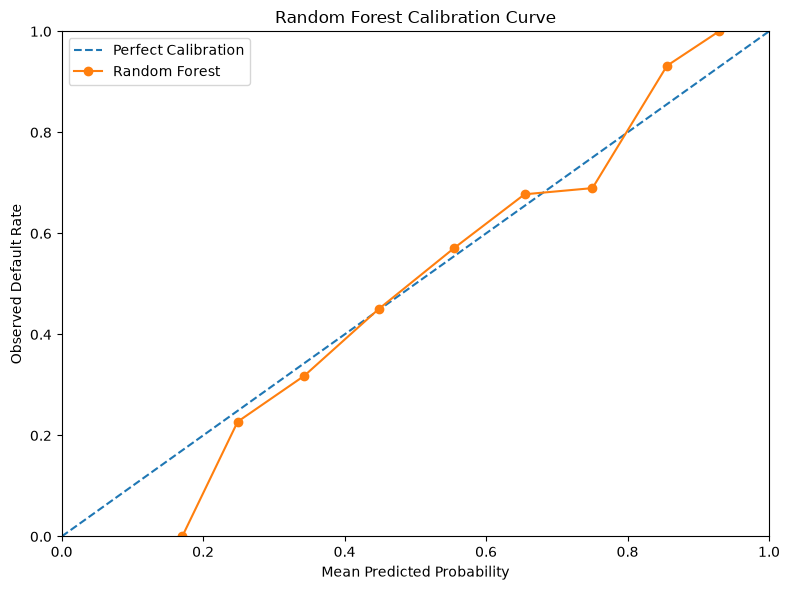

In [105]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

ax.set_title("Random Forest Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Default Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()

chart_path = Path("chart_calibration.png")

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
largest_gap_index = int(np.argmax(calibration_gaps))

largest_gap_predicted = prob_pred[largest_gap_index]
largest_gap_actual = prob_true[largest_gap_index]
largest_gap_value = calibration_gaps[largest_gap_index]

gap_direction = (
    "underestimated default risk"
    if largest_gap_actual > largest_gap_predicted
    else "overestimated default risk"
)

In [107]:
display(Markdown(
    f"""
### 8.2 Largest Calibration Gap

The largest absolute calibration gap was **{largest_gap_value:.4f}**.

In that bin, the mean predicted default probability was
**{largest_gap_predicted:.3f}**, while the observed default rate was
**{largest_gap_actual:.3f}**.

Therefore, in this region the model **{gap_direction}**.

This interpretation is based on the held-out test sample and should
not be treated as a universal property of the model.
"""
))


### 8.2 Largest Calibration Gap

The largest absolute calibration gap was **0.1705**.

In that bin, the mean predicted default probability was
**0.170**, while the observed default rate was
**0.000**.

Therefore, in this region the model **overestimated default risk**.

This interpretation is based on the held-out test sample and should
not be treated as a universal property of the model.


## 8.3 Calibration Conclusion

The final Random Forest model's predicted default probabilities were
evaluated using a calibration curve on the held-out test set.

Calibration measures whether predicted probabilities correspond to
observed default frequencies. The analysis therefore provides
information that is different from accuracy, F1-score, and ROC-AUC.

The calibration results should be interpreted as evidence about the
model on this particular test sample rather than as proof that the
probabilities are reliable for real-world lending decisions.

Before using predicted probabilities for risk-based financial
decisions, calibration should be validated on representative
real-world and out-of-time data and recalibration should be considered
if necessary.

# Required Assessment Artifacts

The following cells generate the required submission files directly from
the evaluated models and analysis results.

The JSON file contains the five required evaluation metrics for every
model, the train-only credit-score imputation value, and the selected
final model.

In [108]:
metric_names = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

model_metrics_output = {
    "baseline": {
        metric: float(baseline_metrics[metric])
        for metric in metric_names
    },
    "logistic_regression": {
        metric: float(logistic_metrics[metric])
        for metric in metric_names
    },
    "decision_tree": {
        metric: float(decision_tree_metrics[metric])
        for metric in metric_names
    },
    "random_forest": {
        metric: float(random_forest_metrics[metric])
        for metric in metric_names
    },
    "credit_score_imputation_value": float(
        credit_score_imputation_value
    ),
    "final_model": final_model_name
}

In [109]:
metrics_path = Path("model_metrics.json")

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(
        model_metrics_output,
        f,
        indent=4
    )

print(f"Created: {metrics_path}")

Created: model_metrics.json


In [110]:
with metrics_path.open("r", encoding="utf-8") as f:
    saved_metrics = json.load(f)

display(Markdown(
    f"""
### `model_metrics.json` Verification

- Models included: **{len(REQUIRED_MODELS) if 'REQUIRED_MODELS' in globals() else 4}**
- Final model: **{saved_metrics["final_model"]}**
- Credit-score imputation value: **{saved_metrics["credit_score_imputation_value"]:.2f}**
- File exists: **{metrics_path.exists()}**
"""
))


### `model_metrics.json` Verification

- Models included: **4**
- Final model: **random_forest**
- Credit-score imputation value: **649.00**
- File exists: **True**


In [111]:
comparison_chart_path = Path("chart_model_comparison.png")

display(Markdown(
    f"""
### Model Comparison Chart

File: `{comparison_chart_path}`

- Exists: **{comparison_chart_path.exists()}**
- File size: **{comparison_chart_path.stat().st_size if comparison_chart_path.exists() else 0:,} bytes**
"""
))


### Model Comparison Chart

File: `chart_model_comparison.png`

- Exists: **True**
- File size: **87,547 bytes**


In [112]:
calibration_chart_path = Path("chart_calibration.png")

display(Markdown(
    f"""
### Calibration Chart

File: `{calibration_chart_path}`

- Exists: **{calibration_chart_path.exists()}**
- File size: **{calibration_chart_path.stat().st_size if calibration_chart_path.exists() else 0:,} bytes**
"""
))


### Calibration Chart

File: `chart_calibration.png`

- Exists: **True**
- File size: **158,676 bytes**


In [113]:
comparison_table = """
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
"""

for model_name in [
    "baseline",
    "logistic_regression",
    "decision_tree",
    "random_forest"
]:
    row = model_comparison.loc[model_name]

    comparison_table += (
        f"| {model_name} "
        f"| {row['accuracy']:.4f} "
        f"| {row['precision']:.4f} "
        f"| {row['recall']:.4f} "
        f"| {row['f1']:.4f} "
        f"| {row['roc_auc']:.4f} |\n"
    )

In [114]:
evaluation_report = f"""# Loan Default Prediction — Evaluation Report

## 1. Task

The objective was to build and evaluate a machine-learning pipeline
for predicting whether a loan applicant will default.

The dataset contains 1,200 synthetic loan applications with the
following predictors:

- Credit score
- Applicant income
- Loan amount
- Employment type

The target variable is `default`, where `1` represents a default and
`0` represents no default.

The data was split into training and test sets using an 80/20 stratified
split with `random_state=42`. Missing credit scores were handled using
the training-set median only.

The training-only credit-score imputation value was
**{credit_score_imputation_value:.2f}**.

## 2. Baseline

A `DummyClassifier` using the `most_frequent` strategy was used as the
baseline.

The baseline achieved:

- Accuracy: **{baseline_metrics["accuracy"]:.4f}**
- Precision: **{baseline_metrics["precision"]:.4f}**
- Recall: **{baseline_metrics["recall"]:.4f}**
- F1: **{baseline_metrics["f1"]:.4f}**
- ROC-AUC: **{baseline_metrics["roc_auc"]:.4f}**

The baseline predicts the majority class for every applicant. Its
ROC-AUC of **{baseline_metrics["roc_auc"]:.4f}** shows that it provides
no meaningful ranking ability beyond chance.

Its recall of **{baseline_metrics["recall"]:.4f}** should therefore not
be interpreted as evidence of a strong model: the baseline achieves
this by predicting the majority class for everyone.

## 3. Model Comparison

The tuned models were evaluated on the same untouched held-out test set.

{comparison_table}

## 4. Final Model Selection

The selected final model is **{final_model_name}**.

The Random Forest achieved:

- Accuracy: **{random_forest_metrics["accuracy"]:.4f}**
- Precision: **{random_forest_metrics["precision"]:.4f}**
- Recall: **{random_forest_metrics["recall"]:.4f}**
- F1: **{random_forest_metrics["f1"]:.4f}**
- ROC-AUC: **{random_forest_metrics["roc_auc"]:.4f}**

Compared with Logistic Regression, Random Forest achieved an accuracy
of **{random_forest_metrics["accuracy"]:.4f}** versus
**{logistic_metrics["accuracy"]:.4f}**, and an F1 score of
**{random_forest_metrics["f1"]:.4f}** versus
**{logistic_metrics["f1"]:.4f}**.

Random Forest also achieved higher ROC-AUC
(**{random_forest_metrics["roc_auc"]:.4f}**) than Logistic Regression
(**{logistic_metrics["roc_auc"]:.4f}**).

Therefore, Random Forest was selected because it provided the strongest
overall held-out test performance among the trained machine-learning
models. The decision was not based on accuracy alone.

## 5. Error Analysis

The final Random Forest produced **{fp_count} false positives** and
**{fn_count} false negatives** on the held-out test set, resulting in
**{total_errors} total misclassified applicants**.

The average predicted default probability was
**{fp_probability:.3f}** for false positives and
**{fn_probability:.3f}** for false negatives.

The error analysis also examined credit score, applicant income,
loan amount, and employment type to identify potential patterns in the
misclassified cases.

The employment category with the highest observed overall test-set
error rate was **{highest_error_employment}**, with an error rate of
**{highest_error_rate:.2%}**.

This is an observation about the test sample rather than evidence that
employment type causes prediction errors.

## 6. Calibration

The Random Forest's predicted default probabilities were evaluated
using a calibration curve with 10 probability bins.

The mean absolute calibration gap was
**{mean_absolute_calibration_gap:.4f}**, while the maximum observed
calibration gap was **{maximum_calibration_gap:.4f}**.

Calibration is different from ROC-AUC. ROC-AUC evaluates how well the
model separates and ranks defaults versus non-defaults, while
calibration evaluates whether predicted probabilities correspond to
observed default frequencies.

Because the model is being evaluated on synthetic data and a single
held-out test set, its probabilities should not automatically be
treated as reliable real-world risk probabilities.

## 7. Honest Limitation

A major limitation is that the dataset does not contain important
real-world lending information such as an applicant's existing debt
obligations or debt-to-income ratio.

Without this information, the model has an incomplete view of an
applicant's ability to repay a loan. In addition, the dataset is
synthetic, so strong test-set performance does not establish that the
model would perform similarly on real lending data.

The model should therefore be treated as an assessment pipeline rather
than a production-ready lending decision system.

## 8. Conclusion

The final pipeline used train-only preprocessing, a stratified
train/test split, a dummy baseline, tuned Logistic Regression,
Decision Tree, and Random Forest models, held-out test evaluation,
error analysis, and calibration analysis.

Random Forest was selected as the final model because it produced the
strongest overall test-set performance among the trained models,
achieving an F1 score of **{random_forest_metrics["f1"]:.4f}** and
ROC-AUC of **{random_forest_metrics["roc_auc"]:.4f}**.

The evaluation also demonstrates that strong classification metrics do
not by themselves establish that predicted probabilities are suitable
for real-world financial decisions.
"""

In [115]:
report_path = Path("evaluation_report.md")

report_path.write_text(
    evaluation_report,
    encoding="utf-8"
)

print(f"Created: {report_path}")

Created: evaluation_report.md


In [116]:
defense_answers = f"""# Defense Answers — ML Pipeline Assessment

## 1. Random Forest vs Logistic Regression

My Random Forest achieved an accuracy of **{random_forest_metrics["accuracy"]:.4f}**
compared with **{logistic_metrics["accuracy"]:.4f}** for Logistic Regression.

This does not mean Logistic Regression should always be the answer.
Model selection should depend on the evaluation criteria and the
behavior of the particular problem. In my experiment, Random Forest
also achieved higher precision (**{random_forest_metrics["precision"]:.4f}**
vs **{logistic_metrics["precision"]:.4f}**), recall
(**{random_forest_metrics["recall"]:.4f}** vs
**{logistic_metrics["recall"]:.4f}**), F1
(**{random_forest_metrics["f1"]:.4f}** vs
**{logistic_metrics["f1"]:.4f}**), and ROC-AUC
(**{random_forest_metrics["roc_auc"]:.4f}** vs
**{logistic_metrics["roc_auc"]:.4f}**).

Therefore, I selected Random Forest because it had stronger overall
held-out test performance in this experiment. The choice is based on
the actual evidence from this dataset, not on the assumption that
Random Forest is always superior.

---

## 2. Why Must Imputation Use Only the Training Data?

The credit-score imputation value was calculated using only the
training portion of the data.

My train-only median was **{credit_score_imputation_value:.2f}**, while
the median calculated from the full dataset was
**{full_dataset_median:.2f}**.

Using the full dataset before splitting would allow information from
the future held-out test set to influence preprocessing of the training
data. Even though the median is not a trained predictive model, it is
still a statistic calculated from the data.

That means the test set would indirectly influence the training
pipeline. This is a form of data leakage and can make the evaluation
less representative of how the pipeline would behave on genuinely
unseen data.

The correct procedure is therefore to calculate the imputation value
from `X_train` only and then apply that fixed value to both `X_train`
and `X_test`.

---

## 3. Accuracy vs Recall for Loan Default

For a loan-default problem, recall on the **default class (`default=1`)**
is particularly important because a false negative means the model
fails to identify an applicant who actually defaults.

My Random Forest achieved a default-class recall of
**{random_forest_metrics["recall"]:.4f}**.

If I optimized only for overall accuracy, I could potentially favor a
model that performs well by predicting the majority class while
missing many actual defaulters. The baseline demonstrates this issue:
it achieved recall of **{baseline_metrics["recall"]:.4f}**, but this
came from predicting the majority class for every applicant, while its
ROC-AUC was only **{baseline_metrics["roc_auc"]:.4f}**.

In practice, optimizing the wrong metric could result in approving
too many risky loans and therefore increasing financial losses.

However, recall should not automatically be maximized without
considering precision and the business cost of false positives.
Rejecting every applicant would produce very high default recall but
would also incorrectly reject many applicants who would repay their
loans.

---

## 4. Calibration and Risk-Based Interest Rates

The calibration curve compares the model's predicted probability of
default with the actual observed default rate within probability bins.

For my final Random Forest, the mean absolute calibration gap was
**{mean_absolute_calibration_gap:.4f}**, and the maximum calibration
gap was **{maximum_calibration_gap:.4f}**.

I would **not directly trust these predicted probabilities to set
risk-based interest rates** without additional validation.

A model can have strong discrimination — my Random Forest achieved a
ROC-AUC of **{random_forest_metrics["roc_auc"]:.4f}** — while still
having imperfect probability calibration.

For a real lending system, I would validate calibration on
representative out-of-time data and consider recalibration methods
such as Platt scaling or isotonic regression if necessary.

Therefore, a predicted probability such as 0.70 should not
automatically be interpreted as exactly 70% real-world default risk
without calibration and production validation.

---

## 5. Important Real-World Factor Missing From the Pipeline

One important missing factor is the applicant's **existing debt
obligations or debt-to-income ratio (DTI)**.

The current pipeline has applicant income and the new loan amount, but
it does not tell us how much debt the applicant is already responsible
for.

Two applicants could have the same income, credit score, and requested
loan amount but have very different repayment capacities because one
may already have substantial outstanding debt.

Without this information, the model has an incomplete view of the
applicant's financial risk. Therefore, even strong performance on this
synthetic test set would not justify using the model directly for real
lending decisions.
"""

In [117]:
defense_path = Path("defense_answers.md")

defense_path.write_text(
    defense_answers,
    encoding="utf-8"
)

print(f"Created: {defense_path}")

Created: defense_answers.md


In [118]:
required_models = {
    "baseline",
    "logistic_regression",
    "decision_tree",
    "random_forest"
}

required_metric_keys = {
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
}

with Path("model_metrics.json").open("r", encoding="utf-8") as f:
    data = json.load(f)

assert required_models <= data.keys()

for model_name in required_models:
    assert required_metric_keys <= data[model_name].keys()

assert "credit_score_imputation_value" in data
assert data["final_model"] in required_models

for model_name in required_models:
    for metric_name in required_metric_keys:
        assert isinstance(data[model_name][metric_name], float)

assert Path("chart_model_comparison.png").exists()
assert Path("chart_model_comparison.png").stat().st_size > 1000

assert Path("chart_calibration.png").exists()
assert Path("chart_calibration.png").stat().st_size > 1000

assert Path("evaluation_report.md").exists()
assert Path("defense_answers.md").exists()

print("All required assessment artifacts passed the structural self-check.")

All required assessment artifacts passed the structural self-check.


In [119]:
artifact_paths = [
    Path("model_metrics.json"),
    Path("chart_model_comparison.png"),
    Path("chart_calibration.png"),
    Path("evaluation_report.md"),
    Path("defense_answers.md")
]

artifact_summary = pd.DataFrame({
    "Artifact": [p.name for p in artifact_paths],
    "Exists": [p.exists() for p in artifact_paths],
    "Size (bytes)": [
        p.stat().st_size if p.exists() else 0
        for p in artifact_paths
    ]
})

display(artifact_summary)

,Artifact,Exists,Size (bytes)
0,model_metrics.json,True,924
1,chart_model_comparison.png,True,87547
2,chart_calibration.png,True,158676
3,evaluation_report.md,True,5053
4,defense_answers.md,True,4560


In [120]:
display(Markdown(
    f"""
# Assessment Submission Ready

The required artifacts have been generated successfully.

### Final Model

**{final_model_name}**

### Final Random Forest Performance

- Accuracy: **{random_forest_metrics["accuracy"]:.4f}**
- Precision: **{random_forest_metrics["precision"]:.4f}**
- Recall: **{random_forest_metrics["recall"]:.4f}**
- F1: **{random_forest_metrics["f1"]:.4f}**
- ROC-AUC: **{random_forest_metrics["roc_auc"]:.4f}**

### Required Files

1. `model_metrics.json`
2. `chart_model_comparison.png`
3. `chart_calibration.png`
4. `evaluation_report.md`
5. `defense_answers.md`

The structural self-check passed successfully.
"""
))


# Assessment Submission Ready

The required artifacts have been generated successfully.

### Final Model

**random_forest**

### Final Random Forest Performance

- Accuracy: **0.7708**
- Precision: **0.7834**
- Recall: **0.8542**
- F1: **0.8173**
- ROC-AUC: **0.8541**

### Required Files

1. `model_metrics.json`
2. `chart_model_comparison.png`
3. `chart_calibration.png`
4. `evaluation_report.md`
5. `defense_answers.md`

The structural self-check passed successfully.
